#Portas lógicas quânticas de 1 qubit

In [ ]:
%%capture
!pip install qiskit[visualization]==1.2.2
!pip install qiskit_aer
!pip install qiskit_ibm_runtime
!pip install matplotlib

In [ ]:
import qiskit
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit
from numpy import pi
from math import sqrt
import qiskit.quantum_info as qi
from qiskit.visualization import plot_histogram

##A representação mais geral para um qubit, é um vetor |ψ> definido no espaço de Hilbert

Nesse exemplo o qubit já foi criado como uma superposição uniforme dos dois estados básicos |0> e |1>.


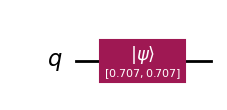

In [ ]:
q = QuantumRegister(1, 'q')
circuito = QuantumCircuit(1)

α = 1/sqrt(2)
β = 1/sqrt(2)

ψ = [α, β]
circuito.initialize(ψ, q[0])

circuito.draw('mpl')

In [ ]:
ψ = qi.Statevector(circuito)
ψ

Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))


In [ ]:
probs = ψ.probabilities()
print(probs)

[0.5 0.5]


In [ ]:
counts = ψ.sample_counts(shots=1024)
print(counts)

{'0': 528, '1': 496}


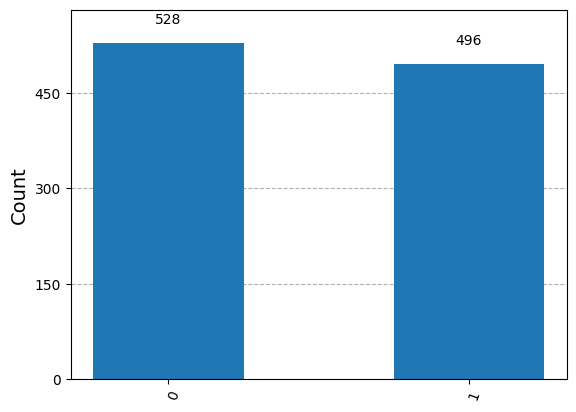

In [ ]:
plot_histogram(counts)

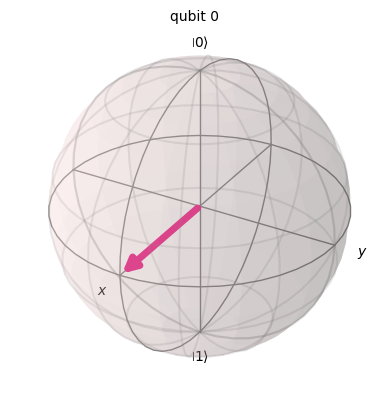

In [ ]:
ψ.draw('bloch')

# Uma outra forma de inicializar o estado mais geral de 1 qubit

Esse é o caso mais simples e mais usual para inicializar o qubit. Perceba que o vetor tem o sentido apontado para o estado |0>, ou seja, isso indica que o qubit não está num estado de superposição.

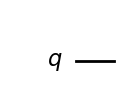

In [ ]:
qc1 = QuantumCircuit(1)
qc1.draw('mpl')

In [ ]:
ψ = qi.Statevector(qc1)
ψ

Statevector([1.+0.j, 0.+0.j],
            dims=(2,))


In [ ]:
probs = ψ.probabilities()
print(probs)

[1. 0.]


In [ ]:
counts = ψ.sample_counts(shots=1024)
print(counts)

{'0': 1024}


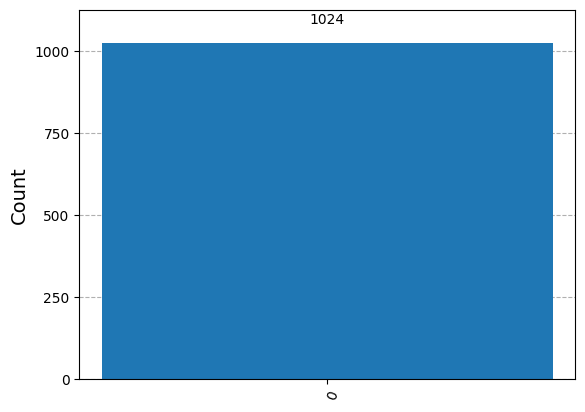

In [ ]:
plot_histogram(counts)

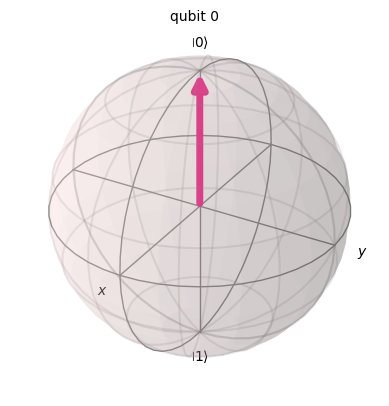

In [ ]:
ψ.draw('bloch')

#Aplicando as portas Hadamard, S e T

Agora que já sabemos inicializar os qubits, podemos aplicar as devidas portas Hadamart e as portas de fase S e T. Vamos aplicar cada uma individualmente e enteder o comportamento delas.

**Atuando com a Porta Hadamart no circuito "qc2"**

A Porta H (Porta de Hadamard) aplica uma transformação que coloca o qubit em uma superposição de estados. Ela faz a transformação:

 H|0⟩ --> 1/√2( |0⟩ + |1⟩ )

 H|1⟩ --> 1/√2( |0⟩ - |1⟩ )  

Ela é crucial para criar superposições, o que permite que o qubit exista em múltiplos estados simultaneamente.

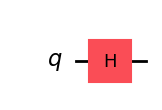

In [ ]:
qc2 = QuantumCircuit(1)
qc2.h(0)
qc2.draw('mpl')

In [ ]:
ψ = qi.Statevector(qc2)
ψ

Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))


In [ ]:
probs = ψ.probabilities()
print(probs)

[0.5 0.5]


In [ ]:
counts = ψ.sample_counts(shots=1024)
print(counts)

{'0': 515, '1': 509}


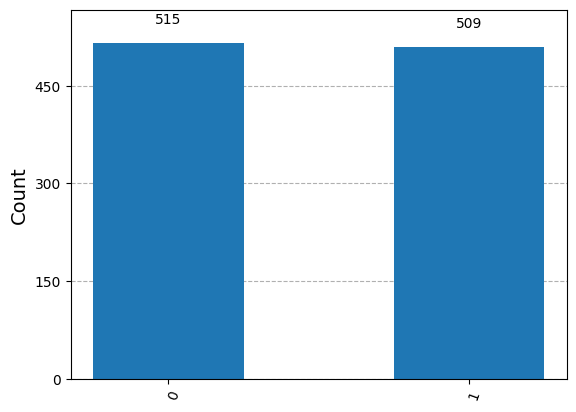

In [ ]:
plot_histogram(counts)

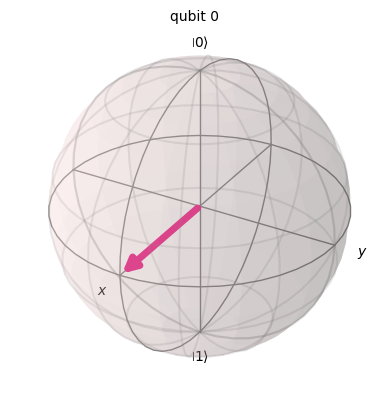

In [ ]:
ψ.draw('bloch')

**Atuando com a Porta de Hadamard no Circuito "qc3"**

O que acontece quando aplicamos a porta Hadamard num qubit que já está em superposição uniforme?

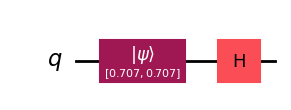

In [ ]:
qc3 = circuito
qc3.h(0)
qc3.draw('mpl')

In [ ]:
ψ = qi.Statevector(qc3)
ψ

Statevector([1.+0.j, 0.+0.j],
            dims=(2,))


In [ ]:
probs = ψ.probabilities()
print(probs)

[1. 0.]


In [ ]:
counts = ψ.sample_counts(shots=1024)
print(counts)

{'0': 1024}


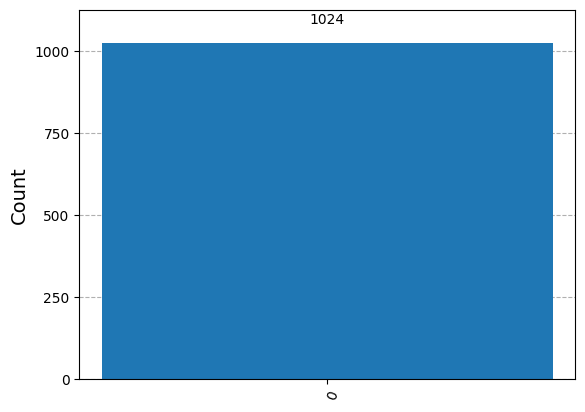

In [ ]:
plot_histogram(counts)

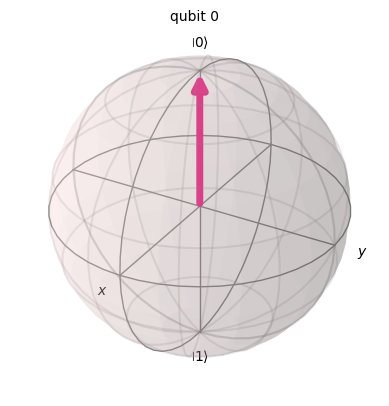

In [ ]:
ψ.draw('bloch')

Portanto, aplicar uma segunda porta Hadamard em um qubit que já está em uma superposição uniforme resultado no estado base ∣ 0 ⟩.

H ( 1/√2   ( |0⟩ + |1⟩)) --> |0⟩  

A porta Hadamard é muitas vezes chamada de "transformada de Fourier discreta de um bit". Quando aplicada a um qubit que já está em superposição, ela atua como uma transformação inversa.


**Atuando com a Porta de Fase S no circuito "qc4"**

Essa porta aplica uma rotação de fase de π/2​ (ou 90°) ao longo do eixo 𝑍. Ela não altera o estado ∣0⟩, mas transforma ∣1⟩ em 𝑖 ∣1⟩, onde 𝑖 é a unidade imaginária. É uma operação fundamental para o controle de fase em circuitos quânticos.

OBS: O circuito qc4 é o mesmo inicial qc1.

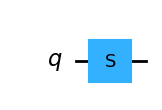

In [ ]:
qc4 = QuantumCircuit(1)
qc4.s(0)
qc4.draw('mpl')

In [ ]:
ψ = qi.Statevector(qc4)
ψ

Statevector([1.+0.j, 0.+0.j],
            dims=(2,))


In [ ]:
probs = ψ.probabilities()
print(probs)

[1. 0.]


In [ ]:
counts = ψ.sample_counts(shots=1024)
print(counts)

{'0': 1024}


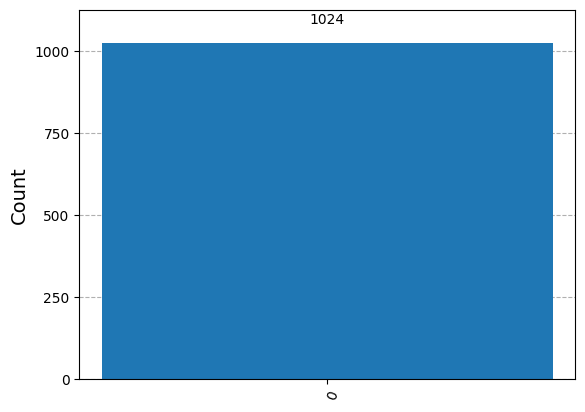

In [ ]:
plot_histogram(counts)

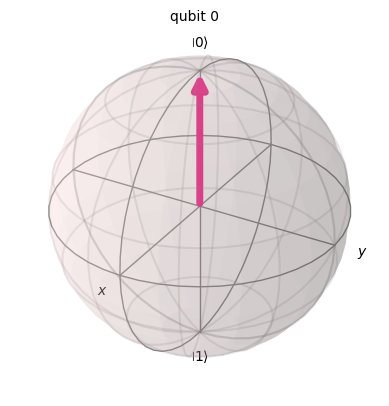

In [ ]:
ψ.draw('bloch')

**Atuando com a Porta de Fase S no Circuito "circuito2"**

Inicialmente criamos o cicuito2 para depois atuar com porta S.

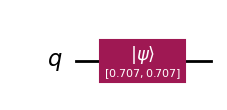

In [ ]:
circuito2 = QuantumCircuit(1)

α = 1/sqrt(2)
β = 1/sqrt(2)

ψ = [α, β]
circuito2.initialize(ψ, q[0])

circuito2.draw('mpl')

In [ ]:
ψ = qi.Statevector(circuito2)
ψ

Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))


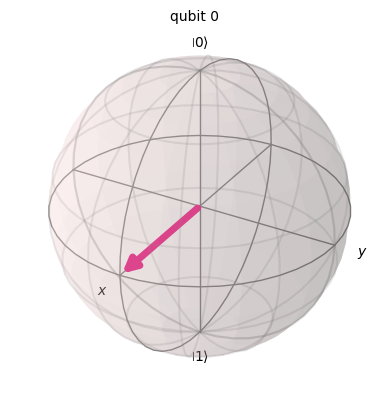

In [ ]:
ψ.draw('bloch')

Agora atua com a Porta de Fase S

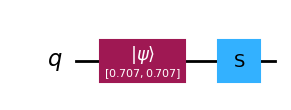

In [ ]:
qc5 = circuito2
qc5.s(0)
qc5.draw('mpl')

In [ ]:
ψ = qi.Statevector(qc5)
ψ

Statevector([0.70710678+0.j        , 0.        +0.70710678j],
            dims=(2,))


In [ ]:
probs = ψ.probabilities()
print(probs)

[0.5 0.5]


In [ ]:
counts = ψ.sample_counts(shots=1024)
print(counts)

{'0': 483, '1': 541}


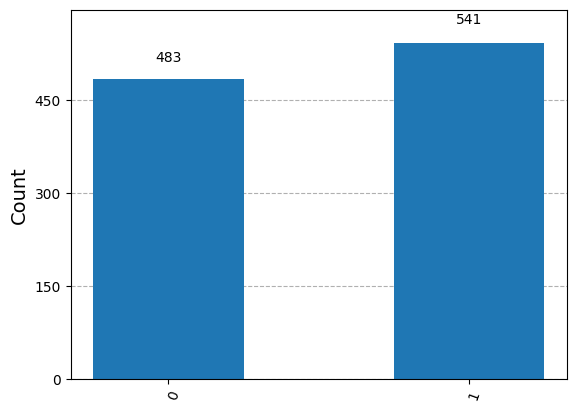

In [ ]:
plot_histogram(counts)

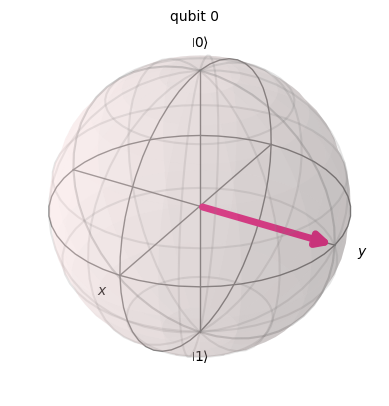

In [ ]:
ψ.draw('bloch')

**Atuando com a Porta de Fase T no circuito "qc6"**

OBS: O circuito qc6 é o mesmo inicial qc1.

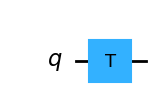

In [ ]:
qc6 = QuantumCircuit(1)
qc6.t(0)
qc6.draw('mpl')

In [ ]:
ψ = qi.Statevector(qc6)
ψ

Statevector([1.+0.j, 0.+0.j],
            dims=(2,))


In [ ]:
probs = ψ.probabilities()
print(probs)

[1. 0.]


In [ ]:
counts = ψ.sample_counts(shots=1024)
print(counts)

{'0': 1024}


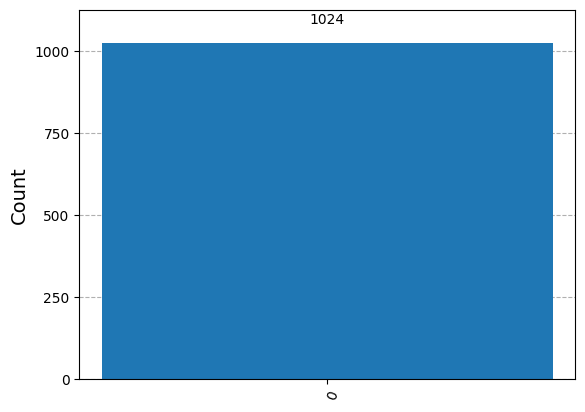

In [ ]:
plot_histogram(counts)

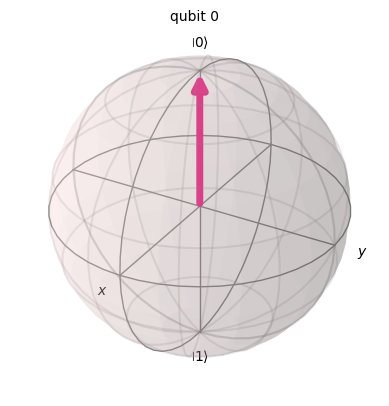

In [ ]:
ψ.draw('bloch')

**Atuando com a Porta de Fase T no Circuito "circuito3"**

Inicialmente criamos o cicuito3 para depois atuar com porta T.

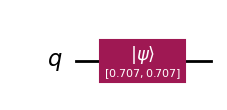

In [ ]:
circuito3 = QuantumCircuit(1)

α = 1/sqrt(2)
β = 1/sqrt(2)

ψ = [α, β]
circuito3.initialize(ψ, q[0])

circuito3.draw('mpl')

In [ ]:
ψ = qi.Statevector(circuito3)
ψ

Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))


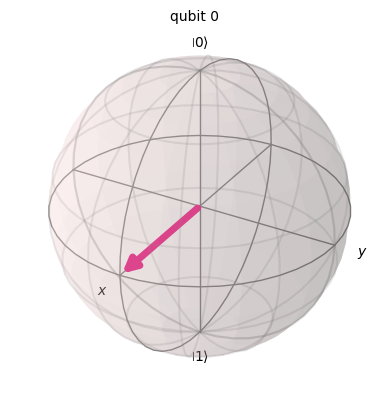

In [ ]:
ψ.draw('bloch')

Agora atua com a Porta de Fase T

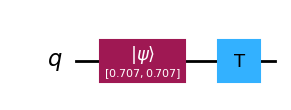

In [ ]:
qc7 = circuito3
qc7.t(0)
qc7.draw('mpl')

In [ ]:
ψ = qi.Statevector(qc7)
ψ

Statevector([0.70710678+0.j , 0.5       +0.5j],
            dims=(2,))


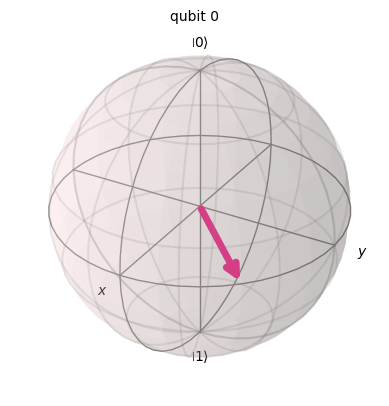

In [ ]:
ψ.draw('bloch')